# 1. feladat – Adatok beolvasása és tisztítása

**Feladat:**  
1. Olvassuk be a `jovedelmek.csv` fájlt Pandas-szal.  
2. Ellenőrizzük az adattípusokat, és állítsuk be a megfelelő típusokat
3. Dobjuk el azokat a sorokat, ahol a **`Jövedelem`** vagy a **`Tapasztalat`** oszlopban **NaN** érték található (`dropna`).  
4. Írjuk ki a képernyőre, hogy **hány rekord maradt** a tisztítás után (`print(len(df))`).  

**Tippek:**
- Pandas függvények: `pd.read_csv()`, `.astype()`, `.dropna(subset=[...], inplace=True)`  
- Ellenőrzés: `df.dtypes`, `df.head()`  
- Rekordok száma: `len(df)` vagy `df.shape[0]`

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

df = pd.read_csv('jovedelmek.csv')
float_oszlopok = ['Életkor', 'Pontszám', 'Jövedelem', 'Tapasztalat']
df[float_oszlopok] = df[float_oszlopok].astype('float64')
df.dtypes
df.dropna(subset=['Jövedelem', 'Tapasztalat'], inplace=True)
df.head()

,Életkor,Pontszám,Jövedelem,Tapasztalat,Osztály,Ország,Szint
0,58.0,63.0,64965.0,12.0,Marketing,India,Középhaladó
1,48.0,75.0,145932.0,21.0,IT,India,Senior
2,34.0,53.0,24648.0,36.0,IT,Németország,Senior
3,62.0,74.0,55133.0,32.0,HR,Brazília,Senior
6,58.0,74.0,114588.0,22.0,HR,Japán,Junior


# 2. feladat – Ékezetek eltávolítása az oszlopnevekből

**Feladat:**  
1. Cseréljük ki a DataFrame oszlopneveit úgy, hogy **ne legyen bennük ékezet**, de a magyar nevek megmaradjanak.  
2. Ellenőrizzük az eredményt a `df.head()` és `df.dtypes` segítségével.  

**Példa:**
| Eredeti oszlopnév | Ékezet nélküli változat |
|------------------|------------------------|
| Életkor           | Eletkor               |
| Jövedelem         | Jovedelem             |
| Pontszám          | Pontszam              |

**Tippek:**  
- Pandas függvény: `.rename(columns={...}, inplace=True)`  
- Ellenőrzéshez: `df.head()`, `df.dtypes`

In [3]:
df.rename(columns={'Életkor': 'Eletkor', 'Jövedelem': 'Jovedelem', 'Pontszám': 'Pontszam'}, inplace=True)
df.head()
#df.dtypes

,Eletkor,Pontszam,Jovedelem,Tapasztalat,Osztály,Ország,Szint
0,58.0,63.0,64965.0,12.0,Marketing,India,Középhaladó
1,48.0,75.0,145932.0,21.0,IT,India,Senior
2,34.0,53.0,24648.0,36.0,IT,Németország,Senior
3,62.0,74.0,55133.0,32.0,HR,Brazília,Senior
6,58.0,74.0,114588.0,22.0,HR,Japán,Junior


# 3. feladat – Tisztított adat mentése CSV-be

**Feladat:**  
1. Mentsük a már ékezetek nélküli, hiányzó értékektől megtisztított DataFrame-et egy új CSV fájlba:  
   - Fájlnév: `tisztitott_jovedelmek.csv`  
   - Elválasztó: `,`  
   - Indexeket **ne** mentsük a fájlba

**Tippek:**  
- Pandas függvény: `.to_csv('fajlnev.csv', index=False, sep=',')`

In [4]:
df.to_csv('tisztitott_jovedelmek.csv', index=False, sep=',')

# 4. feladat – KDE plot FacetGrid-en osztályonként

**Feladat:**  
1. Készítsünk egy **FacetGrid-et**, ahol minden **osztályhoz (Department)** külön sor tartozik.  
2. Rajzoljuk ki az **Jövedelem (Income)** eloszlását **KDE plot** segítségével minden osztályra.  
3. Állítsuk be:
   - Magasság (`height`) = 3  
   - Szélesség/magasság arány (`aspect`) = 2  

**Tippek:**  
- Seaborn függvények: `sns.FacetGrid()`, `.map(sns.kdeplot, "Jovedelem")`  
- Ellenőrzés: `.head()` a DataFrame-en, hogy a 'Department' oszlop rendben van-e.

<bound method NDFrame.head of      Eletkor  Pontszam  Jovedelem  Tapasztalat      Osztály         Ország  \
0       58.0      63.0    64965.0         12.0    Marketing          India   
1       48.0      75.0   145932.0         21.0           IT          India   
2       34.0      53.0    24648.0         36.0           IT    Németország   
3       62.0      74.0    55133.0         32.0           HR       Brazília   
6       58.0      74.0   114588.0         22.0           HR          Japán   
..       ...       ...        ...          ...          ...            ...   
995     54.0      63.0   111598.0         37.0           HR  Franciaország   
996     40.0      63.0   122386.0         23.0    Marketing          Japán   
997     56.0      51.0    66486.0          1.0           IT  Franciaország   
998     24.0      86.0    40567.0         21.0           HR            USA   
999     38.0      54.0    49739.0         16.0  Értékesítés          India   

           Szint  
0    Középhala

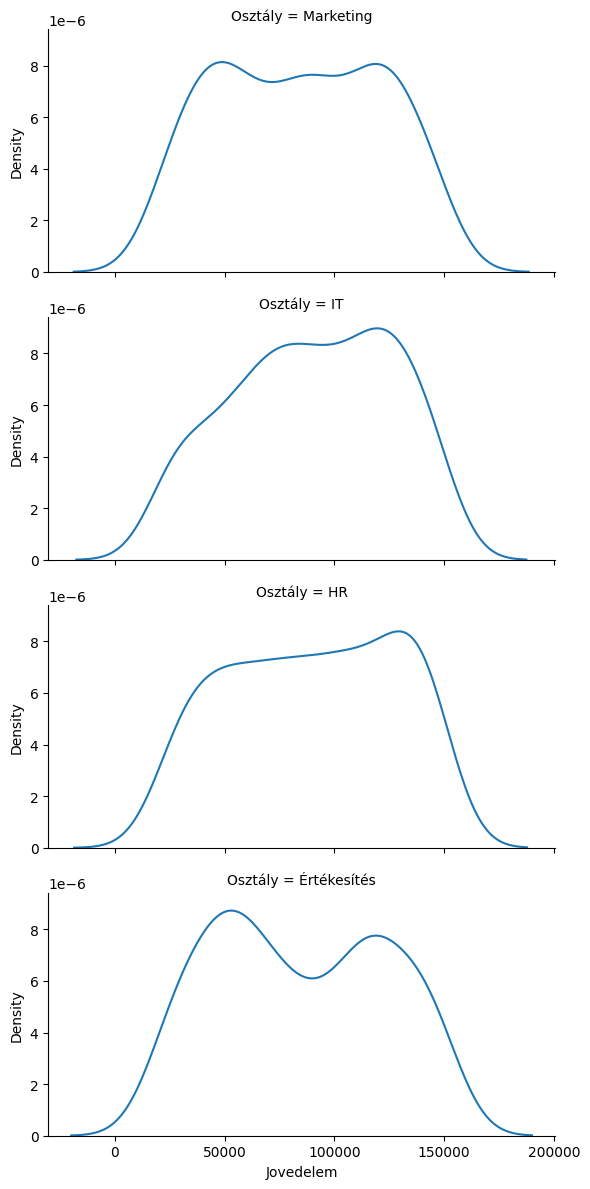

In [6]:
g = sns.FacetGrid(df, row='Osztály', height=3, aspect=2)
g.map(sns.kdeplot, "Jovedelem")

df.head

# 5. feladat – Vonaldiagram az életkor és átlagos jövedelem kapcsolatáról (osztályonként)

**Feladat:**  
1. Készítsünk egy **vonalgrafikont** (`lineplot`), amely megmutatja, hogy az **életkorhoz (Eletkor)** milyen **átlagos jövedelem (Jovedelem)** társul.  
2. Színezzük a vonalakat az **Osztaly** oszlop szerint (`hue='Osztaly'`), így minden osztály külön színt kap.  
3. A grafikonon az **x-tengely** az életkor, a **y-tengely** az átlagos jövedelem legyen.  
4. Paraméterek:
   - Ábra mérete: **figsize=(8,4)**  
   - Átlag számítás: `estimator='mean'`  
   - Hibasáv kikapcsolása: `errorbar=None`  

**Tippek:**  
- Seaborn függvény: `sns.lineplot()`

<Axes: xlabel='Eletkor', ylabel='Jovedelem'>

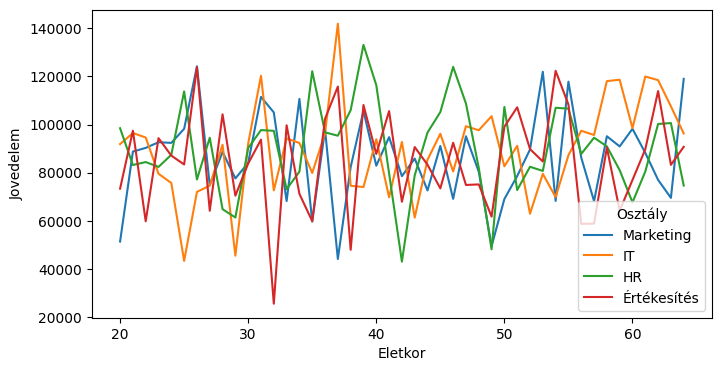

In [7]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df, x='Eletkor',y='Jovedelem',estimator='mean',errorbar=None, hue='Osztály')

# 6. feladat – Scatter plot: Tapasztalat vs. Jövedelem

**Feladat:**  
1. Készítsünk egy **pontdiagramot (scatter plot)**, amely megmutatja, hogyan **alakul a Jövedelem (Jovedelem)** a **Tapasztalat (Tapasztalat)** függvényében.  
2. Paraméterek:
   - X-tengely: **Tapasztalat**  
   - Y-tengely: **Jövedelem**  
   - Pontok színe és mérete alapértelmezett  
   - Ábra mérete: tetszőleges (pl. `figsize=(8,5)`)  

**Tippek:**  
- Seaborn függvény: `sns.scatterplot()` 

<Axes: xlabel='Tapasztalat', ylabel='Jovedelem'>

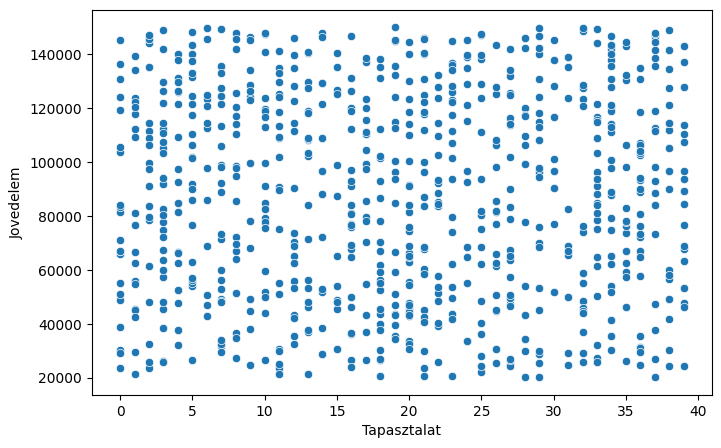

In [8]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Tapasztalat', y='Jovedelem')